# Smart Crop Advisor (Bihar)

## 1) Problem Statement
Farmers in Bihar often need to decide **which crop to grow** based on multiple factors:
- **Soil nutrients** (N, P, K)
- **Weather conditions** (temperature, humidity)
- **Soil condition** (soil type and organic matter)
- **Water availability** (rainfall)

This notebook builds a beginner-friendly ML pipeline that:
1. Loads the crop dataset
2. Uses our newly created Bihar-inspired columns (`soil_type`, `organic_matter`)
3. Performs EDA to understand data patterns
4. Splits data into **train** and **test** sets
5. Trains and compares **4 models**
6. Detects **underfitting/overfitting** using train vs test performance
7. Saves the best model and the soil encoder for the Streamlit app

---

## Notebook Map
- **2) Data Loading & Creation Check**
- **3) EDA**
- **4) Feature Engineering**
- **5) Modeling (Train/Test split + 4 models)**
- **6) Model Comparison**
- **7) Save Model + Encoder**


In [1]:
# 2) Data Loading & Creation Check

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

# Robust project root detection:
# - If you run from project root, it uses CWD
# - If you run from inside notebooks/, it uses CWD.parent
_cwd = Path.cwd()
if (_cwd / "data" / "crop_data.csv").exists():
    PROJECT_ROOT = _cwd
else:
    PROJECT_ROOT = _cwd.parent

DATA_PATH = PROJECT_ROOT / "data" / "crop_data.csv"

df = pd.read_csv(DATA_PATH)
print("Loaded:", DATA_PATH)
df.head()

Loaded: C:\Users\UJJAWAL\OneDrive\Desktop\smart-crop-advisor\data\crop_data.csv


,N,P,K,temperature,humidity,ph,rainfall,label,soil_type,organic_matter
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,loamy,3.02
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice,alluvial,1.35
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice,clay,4.37
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice,alluvial,2.53
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice,alluvial,1.99


### Data Creation (what changed vs the Kaggle dataset)
The original Kaggle dataset has:
- `N, P, K, temperature, humidity, ph, rainfall` as input features
- `label` as the target crop

In **Step 2**, we extended it for a Bihar-focused learning project by adding:
- **`soil_type`** (categorical): simulated using a weighted distribution
  - alluvial (70%), loamy (15%), clay (10%), sandy (5%)
  - This is an *assumption* inspired by typical soil presence in Bihar.
- **`organic_matter`** (numeric): simulated using soil-based ranges with `np.random.uniform()`
  - sandy: 0.5–1.5
  - alluvial: 1.0–3.0
  - loamy: 1.5–4.0
  - clay: 2.0–5.0
  - values rounded to 2 decimals

These two columns help the model learn relationships involving soil category and soil quality.


In [2]:
# Show the new columns clearly

print("Columns:", list(df.columns))
df[["label", "soil_type", "organic_matter"]].head()

Columns: ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label', 'soil_type', 'organic_matter']


,label,soil_type,organic_matter
0,rice,loamy,3.02
1,rice,alluvial,1.35
2,rice,clay,4.37
3,rice,alluvial,2.53
4,rice,alluvial,1.99


## 3) EDA (Exploratory Data Analysis)
EDA helps us answer questions like:
- Which crops appear most in the dataset?
- What is the soil-type distribution after simulation?
- Which numeric features are correlated with each other?

We will create 3 core plots:
1. Crop (`label`) distribution
2. Soil distribution
3. Correlation heatmap for numeric features


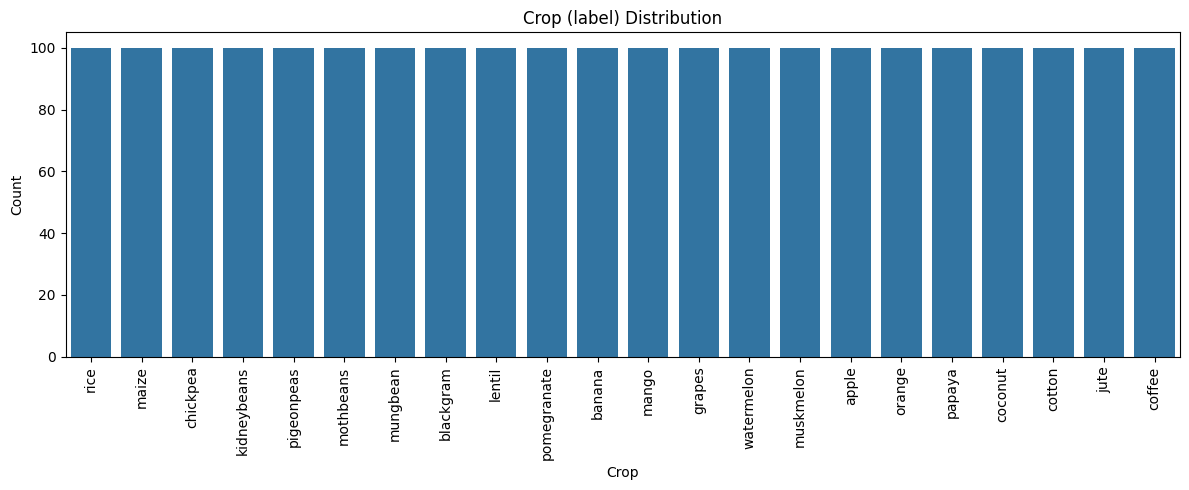

In [3]:
# 3.1 Crop distribution

plt.figure(figsize=(12, 5))
label_counts = df["label"].value_counts()
sns.barplot(x=label_counts.index, y=label_counts.values)
plt.xticks(rotation=90)
plt.title("Crop (label) Distribution")
plt.xlabel("Crop")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

**How to read this plot**
- Each bar is a crop class.
- Taller bars mean that crop appears more times in the dataset.
- This matters because class imbalance can affect model performance (we use `stratify=y` in the train/test split to keep proportions similar).

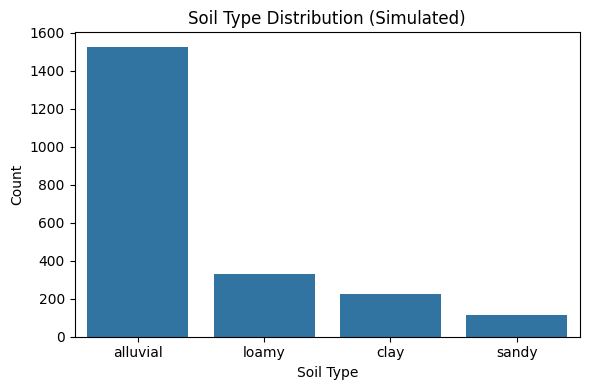

soil_type
alluvial    0.694
loamy       0.150
clay        0.103
sandy       0.053
Name: proportion, dtype: float64

In [4]:
# 3.2 Soil distribution

plt.figure(figsize=(6, 4))
soil_counts = df["soil_type"].value_counts()
sns.barplot(x=soil_counts.index, y=soil_counts.values)
plt.title("Soil Type Distribution (Simulated)")
plt.xlabel("Soil Type")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Also show proportions
(df["soil_type"].value_counts(normalize=True).round(3))

**How to read this plot**
- This plot should roughly match our intended Bihar-inspired weights (alluvial highest).
- Small deviations are normal because we used random sampling.
- This distribution matters because it becomes a learned feature for the model.

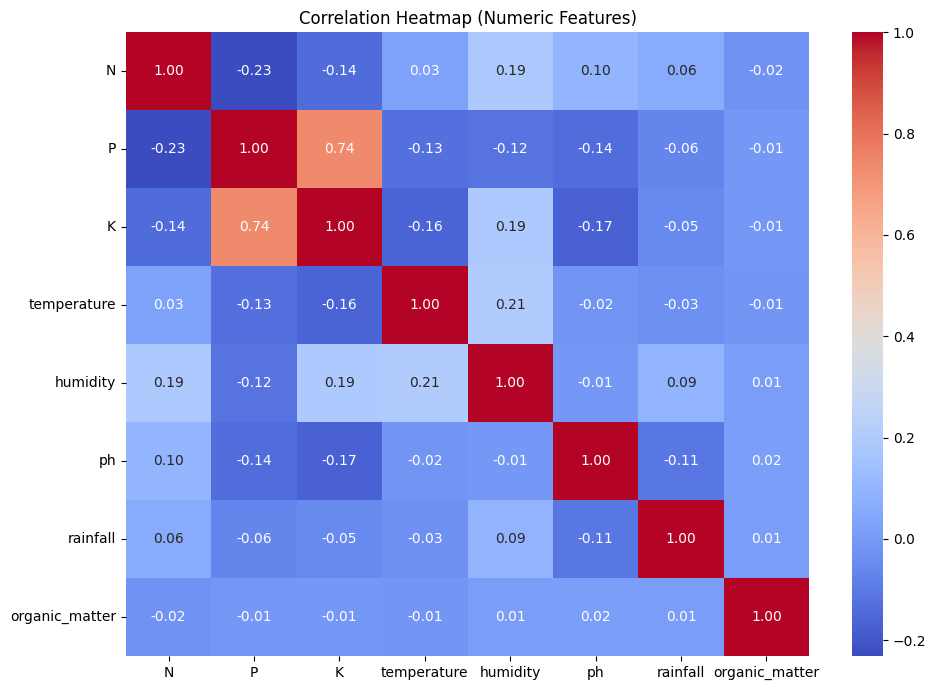

In [5]:
# 3.3 Correlation heatmap (numeric features only)

numeric_df = df.select_dtypes(include=["number"]).copy()

plt.figure(figsize=(10, 7))
corr = numeric_df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap (Numeric Features)")
plt.tight_layout()
plt.show()

**How to read this heatmap**
- Values close to **+1** mean strong positive correlation.
- Values close to **-1** mean strong negative correlation.
- Values near **0** mean weak/no linear relationship.

Correlation does *not* directly tell us which crop is best, but it helps understand feature relationships and potential redundancy.

## 4) Feature Engineering
We need to convert `soil_type` (text) into numbers for ML models.

We will use **Label Encoding**:
- alluvial → 0/1/2/3 (an integer code)

Note: Label encoding assigns an integer to each category. For tree-based models this works well. For linear models, one-hot encoding is often better, but we keep label encoding here to stay beginner-friendly and consistent with saving `soil_encoder.pkl` for the Streamlit app.

In [6]:
from sklearn.preprocessing import LabelEncoder

# --- Encode categorical soil type ---
soil_encoder = LabelEncoder()
df["soil_type_encoded"] = soil_encoder.fit_transform(df["soil_type"])

# --- Add extra engineered features (more signal for the model) ---
# Nutrient interactions
safe_eps = 1e-6

df["npk_sum"] = df["N"] + df["P"] + df["K"]
df["np_ratio"] = df["N"] / (df["P"] + safe_eps)
df["nk_ratio"] = df["N"] / (df["K"] + safe_eps)
df["pk_ratio"] = df["P"] / (df["K"] + safe_eps)

# Balance (high means one nutrient dominates)
df["npk_balance_std"] = df[["N", "P", "K"]].std(axis=1)

# Weather/soil transforms
# (log helps with heavy-tailed rainfall)
df["rainfall_log"] = np.log1p(df["rainfall"])

# Deviation from neutral pH (7 is neutral)
df["ph_distance_from_7"] = (df["ph"] - 7.0).abs()

# Simple combined stress index
# (higher values mean hotter *and* more humid)
df["temp_x_humidity"] = df["temperature"] * df["humidity"]

# Features (X) and target (y)
feature_cols = [
    "N",
    "P",
    "K",
    "npk_sum",
    "np_ratio",
    "nk_ratio",
    "pk_ratio",
    "npk_balance_std",
    "temperature",
    "humidity",
    "temp_x_humidity",
    "ph",
    "ph_distance_from_7",
    "rainfall",
    "rainfall_log",
    "soil_type_encoded",
    "organic_matter",
]

X = df[feature_cols]
y = df["label"]

X.head()

,N,P,K,npk_sum,np_ratio,nk_ratio,pk_ratio,npk_balance_std,temperature,humidity,temp_x_humidity,ph,ph_distance_from_7,rainfall,rainfall_log,soil_type_encoded,organic_matter
0,90,42,43,175,2.142857,2.093023,0.976744,27.428695,20.879744,82.002744,1712.196283,6.502985,0.497015,202.935536,5.317804,2,3.02
1,85,58,41,184,1.465517,2.073171,1.414634,22.188586,21.770462,80.319644,1748.595734,7.038096,0.038096,226.655537,5.427834,0,1.35
2,60,55,44,159,1.090909,1.363636,1.250000,8.185353,23.004459,82.320763,1893.744627,7.840207,0.840207,263.964248,5.579595,1,4.37
3,74,35,40,149,2.114286,1.850000,0.875000,21.221059,26.491096,80.158363,2123.482908,6.980401,0.019599,242.864034,5.496611,0,2.53
4,78,42,42,162,1.857143,1.857143,1.000000,20.784610,20.130175,81.604873,1642.720357,7.628473,0.628473,262.717340,5.574878,0,1.99


## 5) Modeling (Train/Test Split + 4 Models)

### Why Train/Test Split matters
- **Train set**: model learns patterns
- **Test set**: model is evaluated on unseen data (generalization)

### Underfitting vs Overfitting (quick detection)
We will compute **both train accuracy and test accuracy**.
- **Underfit**: train low, test low
- **Overfit**: train very high, test noticeably lower
- **Good fit**: train and test both high and close

We compare these 4 models:
1. Logistic Regression
2. Decision Tree
3. Random Forest
4. Gradient Boosting


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (1760, 17)
Test size: (440, 17)


In [8]:
# Train and evaluate models
# (Imports are repeated here so this cell runs standalone.)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier

models = {
    "LogisticRegression": LogisticRegression(max_iter=5000, n_jobs=None),
    "DecisionTree": DecisionTreeClassifier(random_state=42),
    "RandomForest": RandomForestClassifier(n_estimators=400, random_state=42, n_jobs=-1),
    "ExtraTrees": ExtraTreesClassifier(n_estimators=400, random_state=42, n_jobs=-1),
    "GradientBoosting": GradientBoostingClassifier(random_state=42),
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)

    # Train predictions (to help detect overfit/underfit)
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)

    results.append({
        "model": name,
        "train_accuracy": train_acc,
        "test_accuracy": test_acc,
        "gap(train-test)": train_acc - test_acc,
    })

    print("\n" + "=" * 70)
    print(f"Model: {name}")
    print(f"Train accuracy: {train_acc:.4f}")
    print(f"Test accuracy : {test_acc:.4f}")
    print(f"Gap (train-test): {(train_acc - test_acc):.4f}")
    print("\nClassification report (test set):")
    print(classification_report(y_test, test_pred))

results_df = pd.DataFrame(results).sort_values(by="test_accuracy", ascending=False)
results_df

C:\Users\UJJAWAL\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Model: LogisticRegression
Train accuracy: 0.9909
Test accuracy : 0.9841
Gap (train-test): 0.0068

Classification report (test set):
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.95      0.97        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       0.91      1.00      0.95        20
      grapes       1.00      1.00      1.00        20
        jute       0.87      1.00      0.93        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      0.95      0.97        20
       maize       1.00      0.90      0.95        20
       mango       1.00      1.00      1.00        20
   mothbeans       0.95      1.00      0.98        20
    mungbean       0.95      1.00      0.98        20
  


Model: RandomForest
Train accuracy: 1.0000
Test accuracy : 0.9932
Gap (train-test): 0.0068

Classification report (test set):
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.95      0.97        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      0.95      0.97        20
       maize       0.95      1.00      0.98        20
       mango       1.00      1.00      1.00        20
   mothbeans       0.95      1.00      0.98        20
    mungbean       1.00      1.00      1.00        20
   muskm


Model: ExtraTrees
Train accuracy: 1.0000
Test accuracy : 0.9909
Gap (train-test): 0.0091

Classification report (test set):
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      1.00      1.00        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       0.95      1.00      0.98        20
      grapes       1.00      1.00      1.00        20
        jute       0.91      1.00      0.95        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      0.95      0.97        20
       maize       1.00      0.95      0.97        20
       mango       1.00      1.00      1.00        20
   mothbeans       0.95      1.00      0.98        20
    mungbean       1.00      1.00      1.00        20
   muskmel


Model: GradientBoosting
Train accuracy: 1.0000
Test accuracy : 0.9886
Gap (train-test): 0.0114

Classification report (test set):
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.95      0.97        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.87      1.00      0.93        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      0.95      0.97        20
       maize       0.95      1.00      0.98        20
       mango       1.00      1.00      1.00        20
   mothbeans       0.95      1.00      0.98        20
    mungbean       1.00      1.00      1.00        20
   m

,model,train_accuracy,test_accuracy,gap(train-test)
2,RandomForest,1.000000,0.993182,0.006818
3,ExtraTrees,1.000000,0.990909,0.009091
4,GradientBoosting,1.000000,0.988636,0.011364
0,LogisticRegression,0.990909,0.984091,0.006818
1,DecisionTree,1.000000,0.979545,0.020455


## 6) Model Comparison (choosing the best)
We select the model mainly using **test accuracy** (performance on unseen data).

But we also check the gap between train and test:
- If train is extremely high and test is much lower → likely **overfitting**
- If both are low → **underfitting**

In practice, Random Forest often performs very well for this dataset, but we will use the table above to decide.

In [9]:
# Pick best model by test accuracy
best_row = results_df.iloc[0]
best_model_name = best_row["model"]
print("Best model based on test accuracy:", best_model_name)

best_model = models[best_model_name]
best_row

Best model based on test accuracy: RandomForest


model              RandomForest
train_accuracy              1.0
test_accuracy          0.993182
gap(train-test)        0.006818
Name: 2, dtype: object

## 7) Save Model + Encoder
We save two files in the project root so the Streamlit app can load them:
- `crop_model.pkl` → the trained model
- `soil_encoder.pkl` → the `LabelEncoder` used for `soil_type`

This is important because the app must use the **same encoding mapping** that was used during training.

In [10]:
import joblib

MODEL_PATH = PROJECT_ROOT / "crop_model.pkl"
ENCODER_PATH = PROJECT_ROOT / "soil_encoder.pkl"
FEATURE_COLS_PATH = PROJECT_ROOT / "feature_cols.pkl"

joblib.dump(best_model, MODEL_PATH)
joblib.dump(soil_encoder, ENCODER_PATH)
joblib.dump(feature_cols, FEATURE_COLS_PATH)

print("Saved model        :", MODEL_PATH)
print("Saved soil encoder :", ENCODER_PATH)
print("Saved feature cols :", FEATURE_COLS_PATH)

Saved model        : C:\Users\UJJAWAL\OneDrive\Desktop\smart-crop-advisor\crop_model.pkl
Saved soil encoder : C:\Users\UJJAWAL\OneDrive\Desktop\smart-crop-advisor\soil_encoder.pkl
Saved feature cols : C:\Users\UJJAWAL\OneDrive\Desktop\smart-crop-advisor\feature_cols.pkl
